In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pybaselines import Baseline, utils
from scipy.optimize import curve_fit
from sklearn.metrics import auc, r2_score
from scipy.stats import linregress
from scipy.signal import  peak_widths
import scipy.integrate as integrate
from matplotlib import colormaps
from colorspacious import cspace_converter


In [75]:
path = "."
files = [file for file in os.listdir(path) if  file.endswith('.txt')]
dfs=[]
for file in sorted(files): 
    df = pd.read_csv(file, sep='\t', names=["eV", "intensity"])
    print(file)
    #print(file)
    #display(df)
    dfs.append(df[(df["eV"] >= 1.2) & (df["eV"] <= 2.1)])
power_list= [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.,  1.1, 1.2, 1.3, 1.4]

#print(dfs)


01 CuGaSnS4_532nm_PL_0.1mW--Spectrum--073--Spec.Data 1.txt
02 CuGaSnS4_532nm_PL_0.2mW--Spectrum--074--Spec.Data 1.txt
03 CuGaSnS4_532nm_PL_0.3mW--Spectrum--075--Spec.Data 1.txt
04 CuGaSnS4_532nm_PL_0.4mW--Spectrum--076--Spec.Data 1.txt
05 CuGaSnS4_532nm_PL_0.5mW--Spectrum--077--Spec.Data 1.txt
06 CuGaSnS4_532nm_PL_0.6mW--Spectrum--078--Spec.Data 1.txt
07 CuGaSnS4_532nm_PL_0.7mW--Spectrum--079--Spec.Data 1.txt
08 CuGaSnS4_532nm_PL_0.8mW--Spectrum--080--Spec.Data 1.txt
09 CuGaSnS4_532nm_PL_0.9mW--Spectrum--081--Spec.Data 1.txt
10 CuGaSnS4_532nm_PL_1.0mW--Spectrum--082--Spec.Data 1.txt
11 CuGaSnS4_532nm_PL_1.1mW--Spectrum--083--Spec.Data 1.txt
12 CuGaSnS4_532nm_PL_1.2mW--Spectrum--084--Spec.Data 1.txt
13 CuGaSnS4_532nm_PL_1.3mW--Spectrum--085--Spec.Data 1.txt
14 CuGaSnS4_532nm_PL_1.4mW--Spectrum--086--Spec.Data 1.txt


In [4]:


power_legend= [str(s)+" mW" for s in power_list]
rev = power_legend[::-1]
print(power_list)
print(rev)

[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]
['1.4 mW', '1.3 mW', '1.2 mW', '1.1 mW', '1.0 mW', '0.9 mW', '0.8 mW', '0.7 mW', '0.6 mW', '0.5 mW', '0.4 mW', '0.3 mW', '0.2 mW', '0.1 mW']


In [5]:
for index, df in enumerate(dfs):
    x= df["eV"]
    y= df["intensity"]
    baseline_fitter = Baseline(x_data=x)
    bkg_1, params_1 = baseline_fitter.modpoly(y, poly_order=1)
    df["intensity-bkg"] = y - bkg_1

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pybaselines/polynomial.py:217: RuntimeWarning: divide by zero encountered in matmul
  baseline = self._polynomial.vandermonde @ coef
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pybaselines/polynomial.py:217: RuntimeWarning: overflow encountered in matmul
  baseline = self._polynomial.vandermonde @ coef
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pybaselines/polynomial.py:217: RuntimeWarning: invalid value encountered in matmul
  baseline = self._polynomial.vandermonde @ coef
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pybaselines/polynomial.py:229: RuntimeWarning: divide by zero encountered in matmul
  baseline = self._polynomial.vandermonde @ coef
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pybaselines/polynomial.py:229: RuntimeWarning: overflow encountered in matm

In [6]:
display(df)
power_legend= [str(s)+" mW" for s in power_list]
rev = power_legend[::-1]

,eV,intensity,intensity-bkg
210,2.09979,2080.0,-113.639471
211,2.09856,2068.0,-125.420571
212,2.09733,2051.0,-142.201672
213,2.09610,2106.0,-86.982772
214,2.09487,2125.0,-67.763872
...,...,...,...
1497,1.20161,1911.0,-122.792744
1498,1.20121,1926.0,-107.721557
1499,1.20081,1885.0,-148.650371
1500,1.20042,1894.0,-139.580963


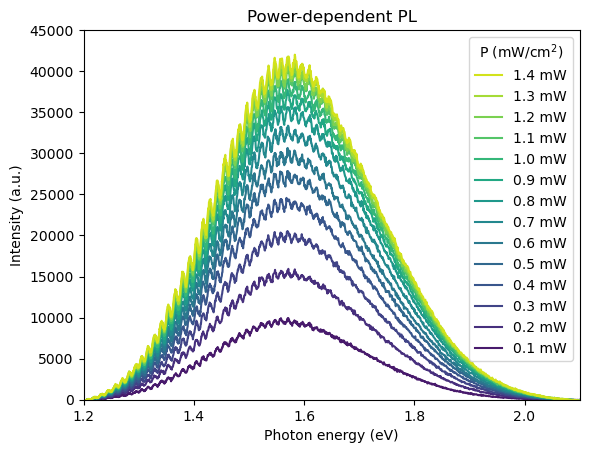

<Figure size 640x480 with 0 Axes>

In [167]:
#colour_map = plot_color_gradients('Perceptually Uniform Sequential', ["viridis"])
                                  
for index, df in enumerate(dfs):
    x= df["eV"]
    y= df["intensity"]
    y_corrected= df["intensity-bkg"]
    #plt.plot(x, y, label='raw data', lw=1.5)
    #plt.plot(x, bkg_1, '--', label='modpoly')
    with sns.color_palette("viridis", n_colors=14):

        plt.plot(x, y_corrected, '-',  label=power_legend[index])

    #plt.text(1.25, 35000, "CuGaSnS4", fontsize=10)
    #plt.text(1.25, 32000, "532 nm ", fontsize=10)

    #plt.show()
title="Power-dependent PL"
plt.title(title)
plt.legend(title="P (mW/cm$^2$)", reverse=True)
plt.ylabel("Intensity (a.u.)")
plt.xlabel("Photon energy (eV)")
plt.ylim(0, 45000)
plt.xlim(1.2, 2.1)

plt.show()
plt.savefig("power_dependance.jpg")

### new approach

In [118]:

colors=sns.color_palette("viridis")   
print(colors)
sns.color_palette("viridis")   

[(0.275191, 0.194905, 0.496005), (0.212395, 0.359683, 0.55171), (0.153364, 0.497, 0.557724), (0.122312, 0.633153, 0.530398), (0.288921, 0.758394, 0.428426), (0.626579, 0.854645, 0.223353)]


[(0.275191, 0.194905, 0.496005),
 (0.212395, 0.359683, 0.55171),
 (0.153364, 0.497, 0.557724),
 (0.122312, 0.633153, 0.530398),
 (0.288921, 0.758394, 0.428426),
 (0.626579, 0.854645, 0.223353)]

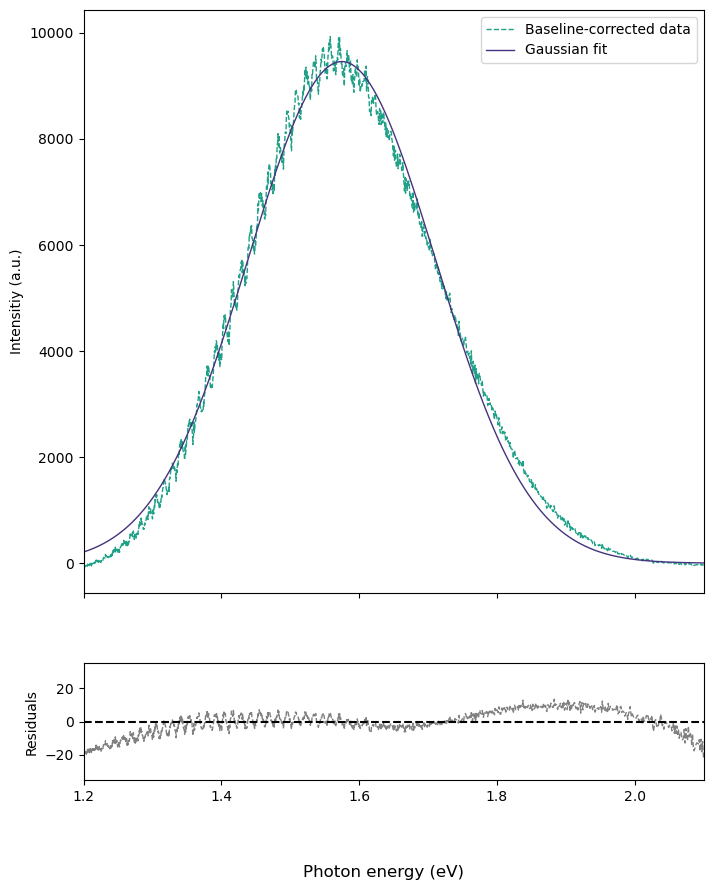

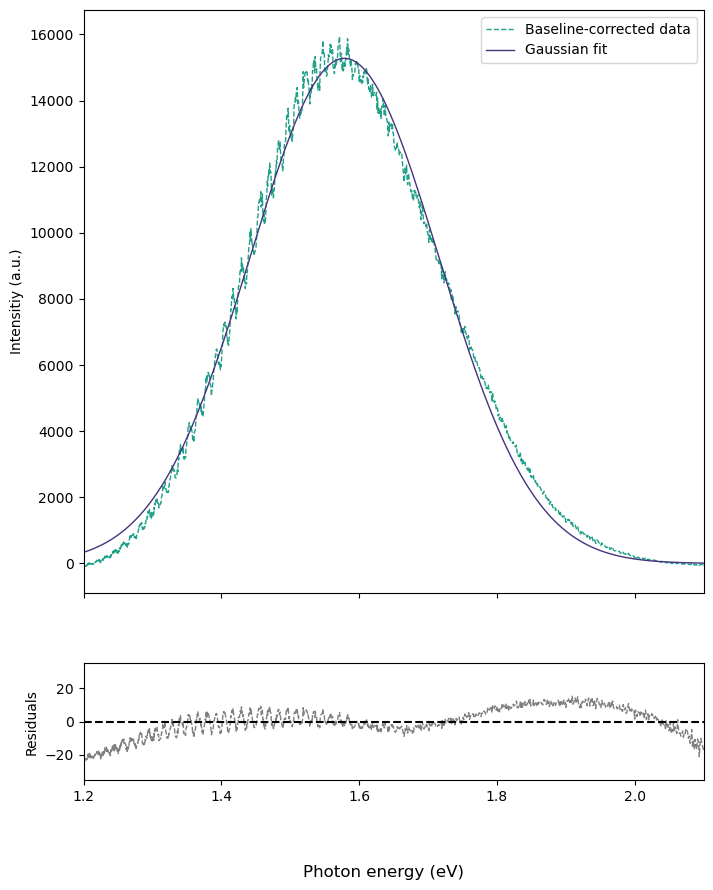

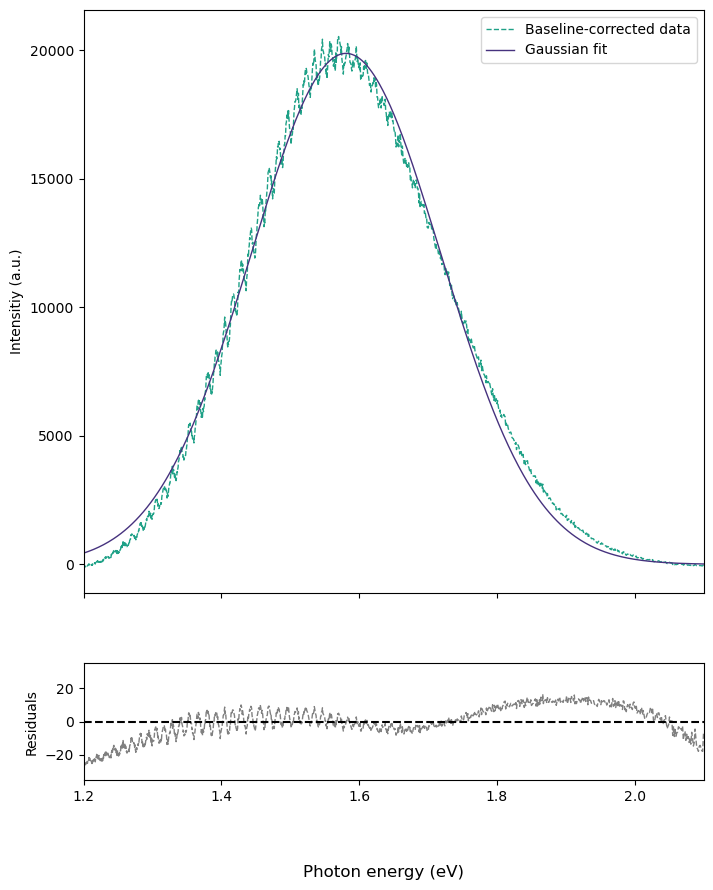

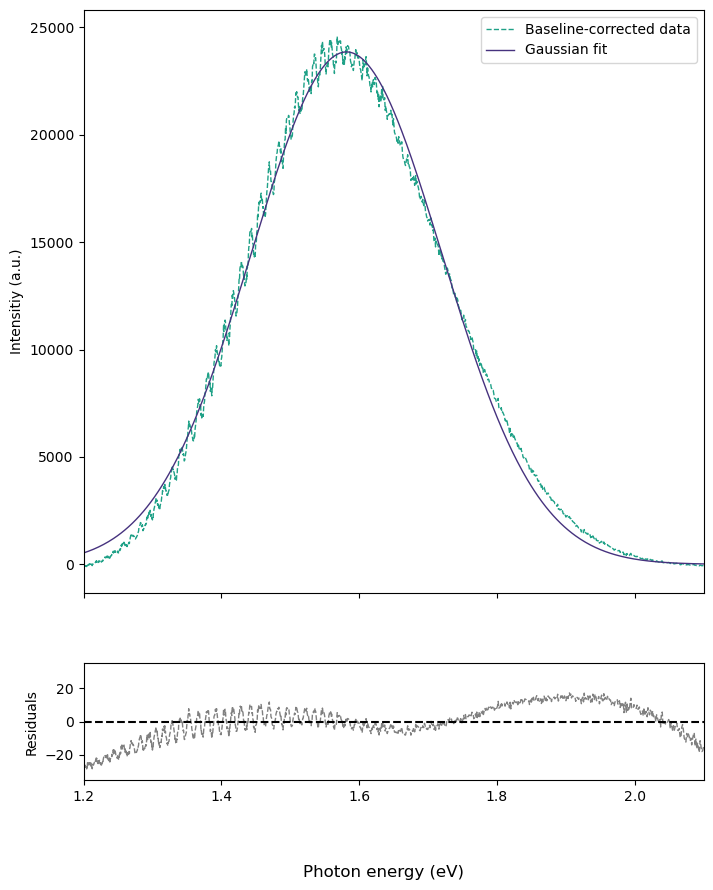

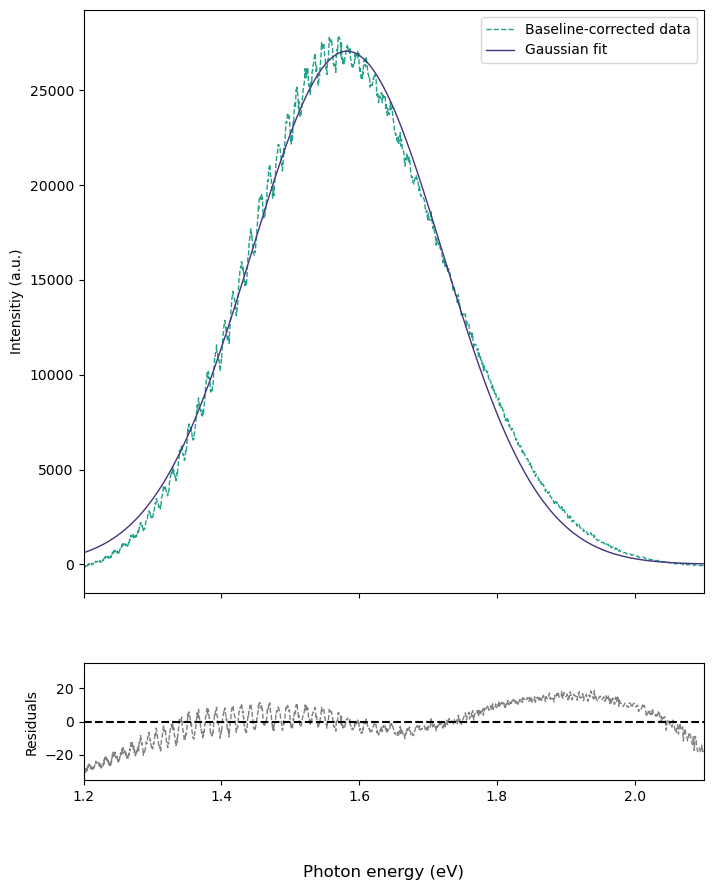

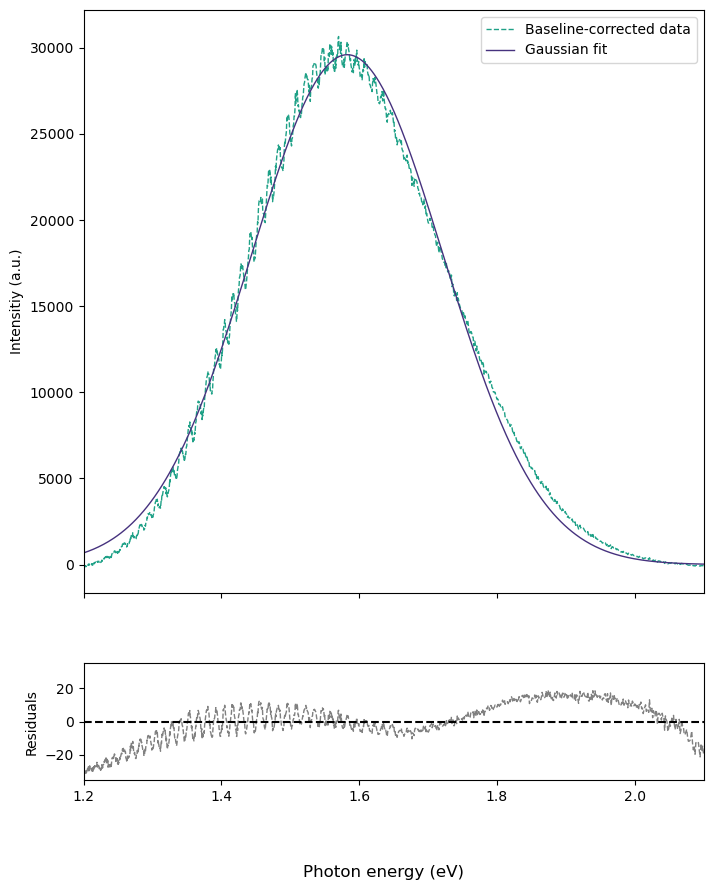

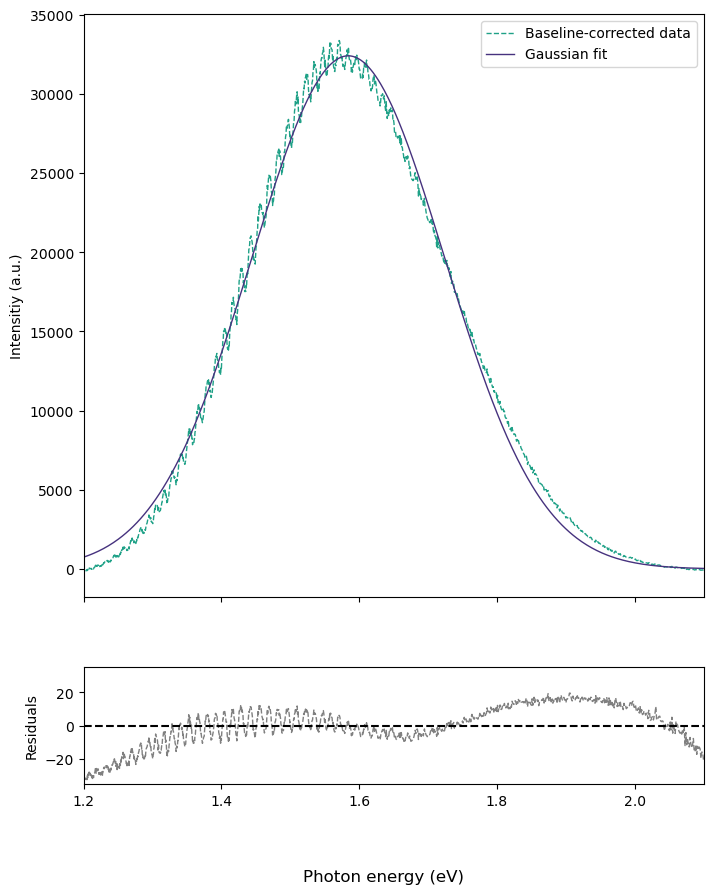

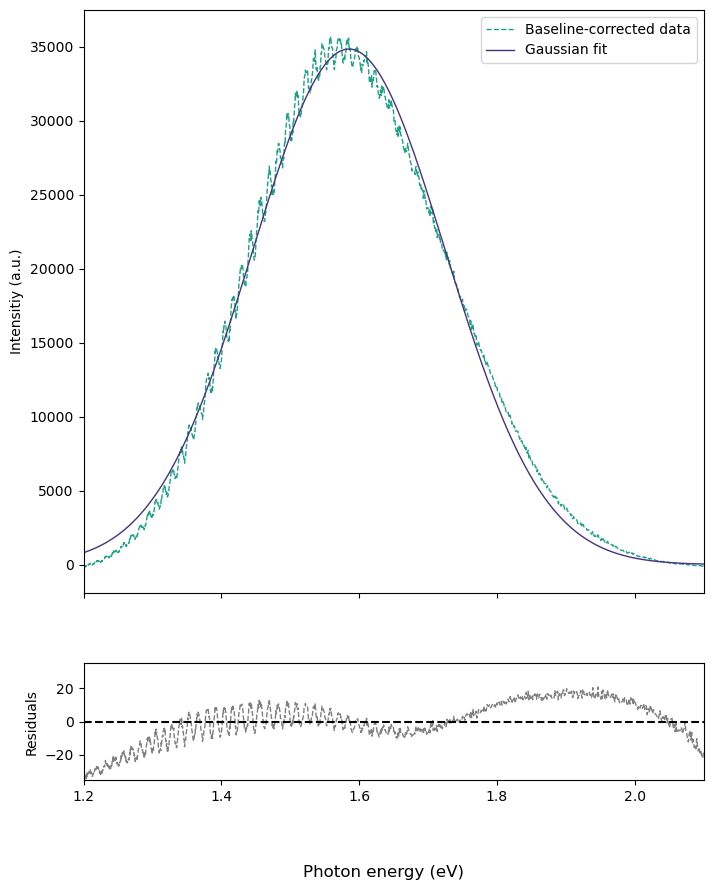

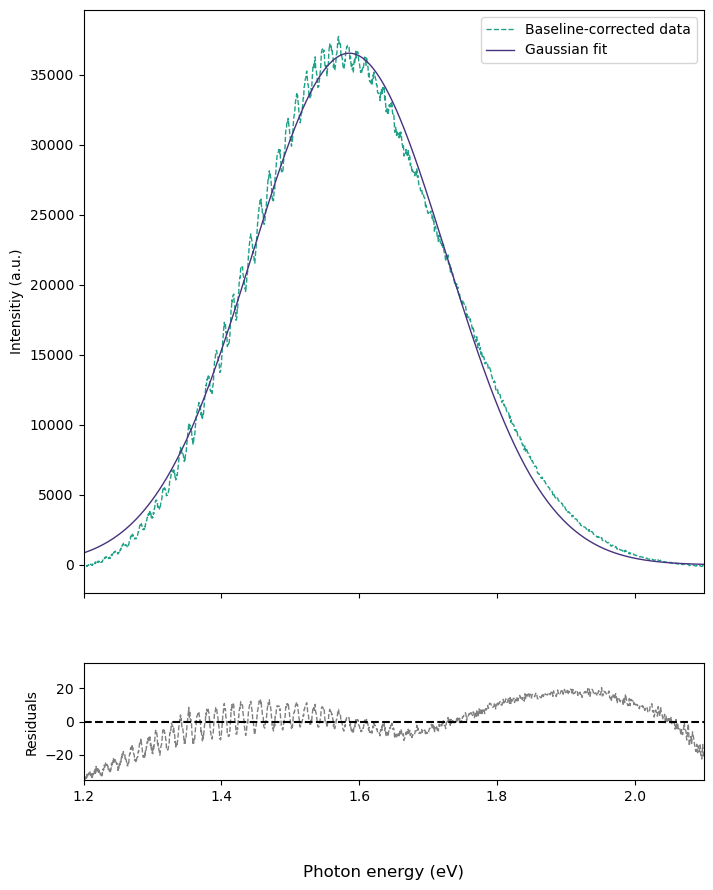

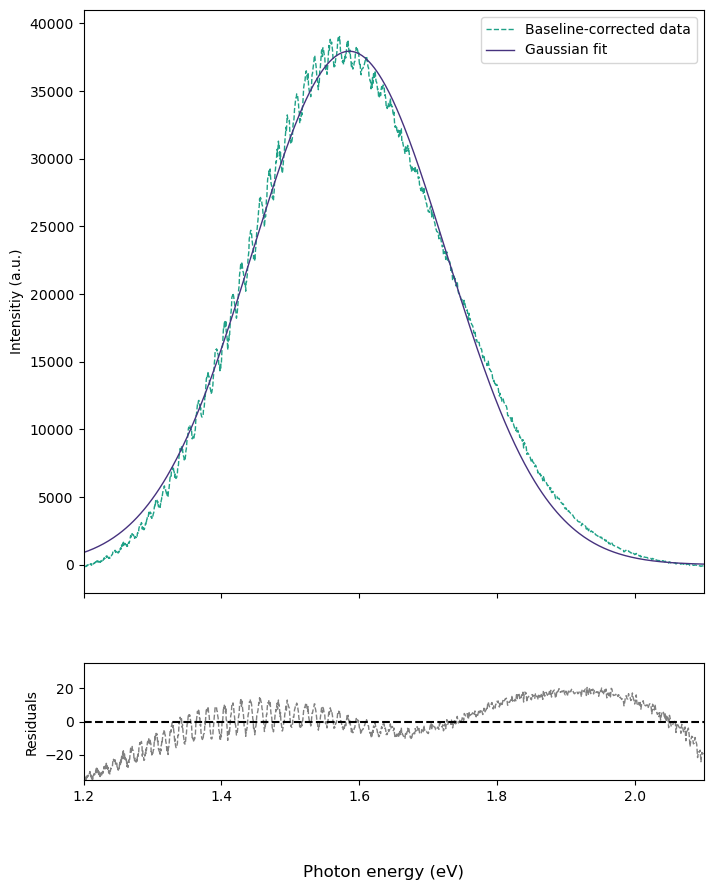

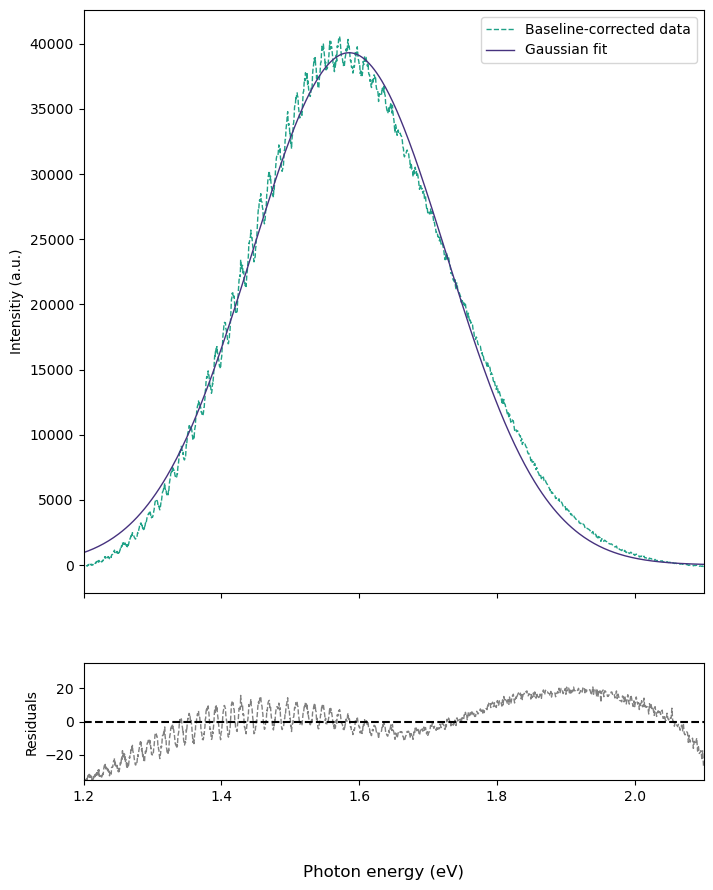

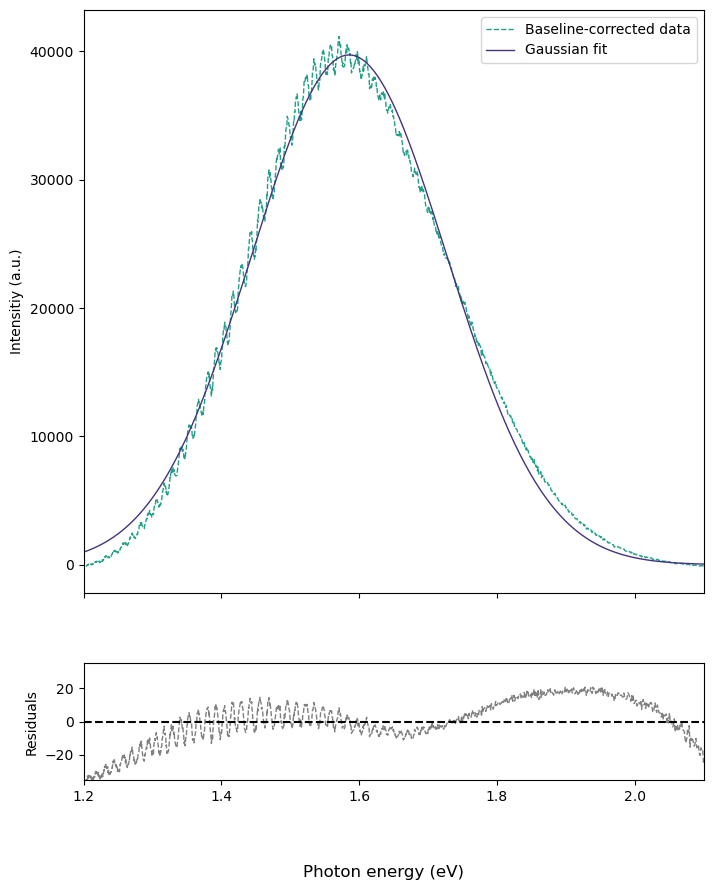

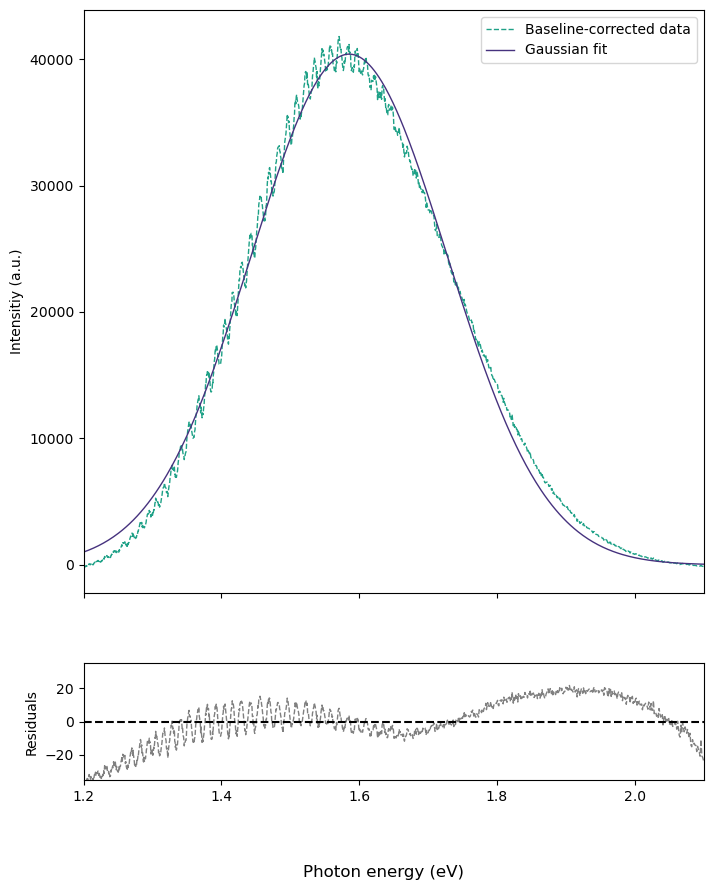

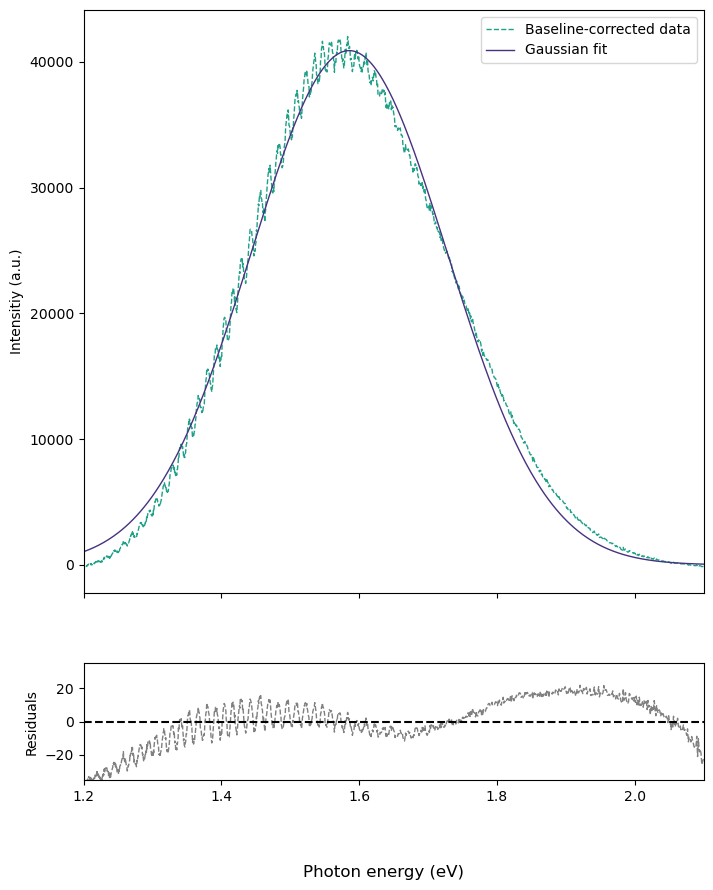

In [184]:
#x, y inputs can be lists or 1D numpy arrays

def gauss(x, mu, sigma, A):
    return A*np.exp(-(x-mu)**2/2/sigma**2)


def fit(x, y, power):
    params, cov = curve_fit(gauss, x, y, (1.6, .2, 10000)) 

    # residuals 
    x_fit = np.linspace(x.min(), x.max(), 500)
    y_pred= gauss(x, *params)
    # print(y_pred)
    # print(y)
    residuals = (y- y_pred)/np.sqrt(y_pred)

   
    y_max = max(y)

    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y-np.mean(y))**2)
    r_squared = 1 - (ss_res / ss_tot)
    r2score=r2_score(y, y_pred)

    sigma=np.sqrt(np.diag(cov))
    
    #plot combined...
    #plt.plot(x_fit, bimodal(x_fit, *params), color='red', lw=3, label='model')
    #...and individual Gauss curves
    peak_1= gauss(x_fit, *params[:3])
    #plt.plot(x_fit, peak_1, color='red', lw=1, ls="--", label='Gaussian fit')
    #plt.show() 

    mu=params[0]
    sigma1=params[1]
    A= params[2]
    #alternative area under the curve
    def make_gauss(x):
        return A*np.exp(-(x-mu)**2/2/sigma1**2) 
    mu=params[0]

    A= params[2]
    result, error = integrate.quad(make_gauss, 1.2, 2.1)

    #and the original data points if no histogram has been created before
    #plt.plot(x, y, color="black", lw=1,ls="--",  label="baseline-corrected data")
    # plt.legend()
    # plt.title(f"{power} mW")
    #plt.show()
    
    params_df_1= pd.DataFrame(data={'params': params, 'sigma': sigma}, index=gauss.__code__.co_varnames[1:])


    # peak pos +- 2.355/2 * sigma
    fwhm_1_1 = params[0] - (2.355/2) * params[1]
    fwhm_1_2 = params[0] + (2.355/2) * params[1]
    fwhm= 2.355 * params[1]
    fwhm_error = fwhm*sigma[1]

    #final metrics
    peak_pos = params[0]
    peak_err = sigma[0]
    plt.show() 



     # plots
    
    # # Upper plot
    # fig1 = plt.figure(1)
        
    # frame1 = fig1.add_axes((.1,.3,.8,.6))

    # plt.plot(x, y, lw=1,ls="--", color= (0.122312, 0.633153, 0.530398), label="baseline-corrected data")
    # plt.plot(x_fit, peak_1,  lw=1, ls="--", color= (0.275191, 0.194905, 0.496005), label='Gaussian fit')
    # plt.title(f"Excitation power {power} mW")
    # frame1.set_xticklabels([]) 
    # plt.ylabel("Intensitiy (a.u.)")
        
    # plt.xlim(1.2, 2.1)
    # plt.grid()

    # # Residual plot
    # frame2 = fig1.add_axes((.1,.1,.8,.2))        
    # plt.plot(x, residuals,lw=1, color="gray", ls="--")
    # plt.ylabel("Residuals")
    # plt.grid()


    
    #### try again
    fig, (ax1, ax2) = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [5, 1]})
    fig.set_figwidth(8)
    fig.set_figheight(10)
    ax1.plot(x, y, lw=1,ls="--", color= (0.122312, 0.633153, 0.530398), label="Baseline-corrected data")
    ax1.plot(x_fit, peak_1,  lw=1, ls="-", color= (0.275191, 0.194905, 0.496005), label='Gaussian fit')
    plt.ylim(0, y_max)
    plt.xlim(1.2,2.1)
    ax1.legend()
    ax2.plot(x, residuals,lw=1, color="gray", ls="--")
    ax2.axhline(y=0, color='black', linestyle='--')
    plt.ylim(-35, 35)

    ax1.set_ylabel("Intensitiy (a.u.)")
    ax2.set_ylabel("Residuals")
    fig.supxlabel("Photon energy (eV)")
    #fig.suptitle(f"Excitation power {power} mW")
     
    # sns.scatterplot(y=residuals, x=x)
    # plt.axhline(y=0, color='r', linestyle='--')
    #plt.savefig(f"gauss_fit_{power}_mW.pdf", format='pdf')
    plt.show()

    
    return peak_pos, peak_err, result, error, fwhm, fwhm_error, residuals, r2score



peak_pos_list= []
peak_err_list= []
area_list=[]
area_error_list=[]
fwhm_list=[]
fwhm_error_list=[]
residuals_list=[]
r2_list=[]

for index, df in enumerate(dfs):
    y = df["intensity-bkg"]
    x= df["eV"]
    power= power_list[index]
    

    peak_pos, peak_err, result, error, fwhm, fwhm_error, residuals, r_squared  = fit(x, y, power) 

    peak_pos_list.append(peak_pos)
    peak_err_list.append(peak_err)
    area_list.append(result)
    area_error_list.append(error)
    fwhm_list.append(fwhm)
    fwhm_error_list.append(fwhm_error)
    residuals_list.append(residuals)
    r2_list.append(r_squared)

# print(peak_pos_list)
# print(peak_err_list)
# print(area_list)
# print(area_error_list)
# print(fwhm_list)
# print(fwhm_error_list)
metrics = pd.DataFrame({"excitation power": power_legend, 'peak position': peak_pos_list,'peak position error': peak_err_list, 
                        'area': area_list,'area error': area_error_list,
                        'FWHM': fwhm_list,'FWHM error': fwhm_error_list,
                        'R$^2$': r2_list})


# sns.scatterplot(y=residuals_list[3], x=dfs[3]["eV"])
# plt.axhline(y=0, color='r', linestyle='--')
# plt.show()

In [139]:
display(metrics.round(3))

,excitation power,peak position,peak position error,area,area error,FWHM,FWHM error,R$^2$
0,0.1 mW,1.575,0.0,3212.626,0.0,0.320,0.0,0.995
1,0.2 mW,1.579,0.0,5234.511,0.0,0.323,0.0,0.995
2,0.3 mW,1.581,0.0,6848.507,0.0,0.325,0.0,0.995
3,0.4 mW,1.582,0.0,8250.867,0.0,0.326,0.0,0.995
4,0.5 mW,1.582,0.0,9399.436,0.0,0.327,0.0,0.995
5,0.6 mW,1.583,0.0,10307.254,0.0,0.328,0.0,0.995
6,0.7 mW,1.584,0.0,11327.731,0.0,0.329,0.0,0.995
7,0.8 mW,1.585,0.0,12232.179,0.0,0.331,0.0,0.995
8,0.9 mW,1.586,0.0,12851.244,0.0,0.332,0.0,0.995
9,1.0 mW,1.586,0.0,13376.787,0.0,0.332,0.0,0.995


[-1.         -0.69897    -0.52287875 -0.39794001 -0.30103    -0.22184875
 -0.15490196 -0.09691001 -0.04575749  0.          0.04139269  0.07918125
  0.11394335  0.14612804]


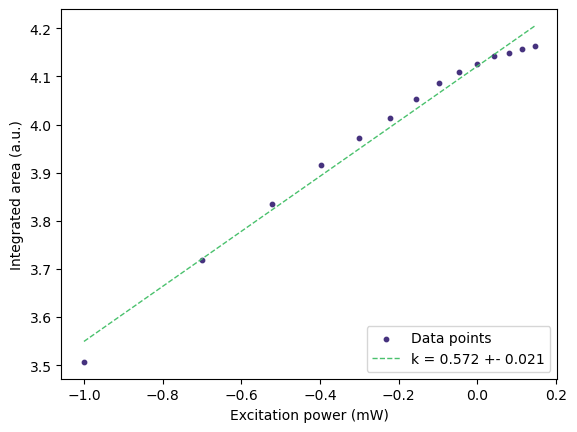

LinregressResult(slope=np.float64(0.5720962741598314), intercept=np.float64(4.121499085685162), rvalue=np.float64(0.9921813442486825), pvalue=np.float64(3.243374294732722e-12), stderr=np.float64(0.02077389441281897), intercept_stderr=np.float64(0.008118073223227242))


<Figure size 640x480 with 0 Axes>

In [164]:
log_x = np.log10(power_list)
print(log_x)
log_y= np.log10(area_list)
log_y_err=np.log10(area_error_list)

res = linregress(log_x, log_y) 
y_pred= res.slope * log_x + res.intercept

k = res.slope.round(3)
k_err= res.stderr.round(3)
r2=res.rvalue


plt.scatter(log_x, log_y, marker='o', color=(0.275191, 0.194905, 0.496005), s=10, label='Data points')

#plt.errorbar(log_x, log_y, yerr=log_y_err, fmt='o', color="olive", ecolor="black", capsize=4, ms=3,label="Data with error")


plt.plot(log_x, y_pred, color=(0.288921, 0.758394, 0.428426), lw=1, ls="--", label=f'k = {k} +- {k_err}')

plt.legend(loc='lower right')
plt.xlabel("Excitation power (mW)")
plt.ylabel("Integrated area (a.u.)")
# plt.text(-.8, 4, 'k = 0.572 +- 0.021', fontsize=10)
# plt.text(-.8, 3.95, 'r$^2$ = 0.992', fontsize=10)
# plt.xscale('log')
# plt.yscale('log')
#plt.title("Fitted power law dependance")
plt.show()
plt.savefig("k_val.jpg")
print(res)

### restricted range

In [128]:
print(power_list[:8])

[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]


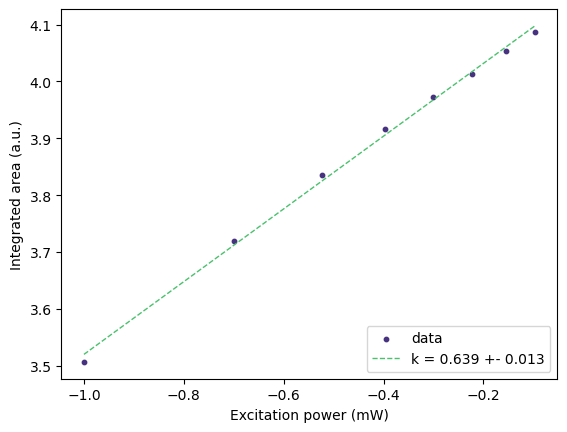

LinregressResult(slope=np.float64(0.6394282569433155), intercept=np.float64(4.1595311845424225), rvalue=np.float64(0.9987810428802331), pvalue=np.float64(4.523849718185315e-09), stderr=np.float64(0.012900980933781642), intercept_stderr=np.float64(0.006599610871762485))


<Figure size 640x480 with 0 Axes>

In [182]:
log_x = np.log10(power_list[:8])
log_y= np.log10(area_list[:8])
log_y_err=np.log10(area_error_list[:8])

res = linregress(log_x, log_y) 
y_pred= res.slope * log_x + res.intercept

k = res.slope.round(3)
k_err= res.stderr.round(3)
r2=res.rvalue


plt.scatter(log_x, log_y, marker='o', color=(0.275191, 0.194905, 0.496005), s=10, label='data')

#plt.errorbar(log_x, log_y, yerr=log_y_err, fmt='o', color="olive", ecolor="black", capsize=4, ms=3,label="Data with error")


plt.plot(log_x, y_pred, color= (0.288921, 0.758394, 0.428426), lw=1, ls="--", label=f'k = {k} +- {k_err}')

plt.legend(loc='lower right')
plt.xlabel("Excitation power (mW)")
plt.ylabel("Integrated area (a.u.)")
# plt.text(-.8, 4, 'k = 0.572 +- 0.021', fontsize=10)
# plt.text(-.8, 3.95, 'r$^2$ = 0.992', fontsize=10)
# plt.xscale('log')
# plt.yscale('log')
#plt.title("Power law restricted range 0.1 - 0.8 eV")
plt.show()
plt.savefig("figs/power_law_restricted.png", format='png')
print(res)

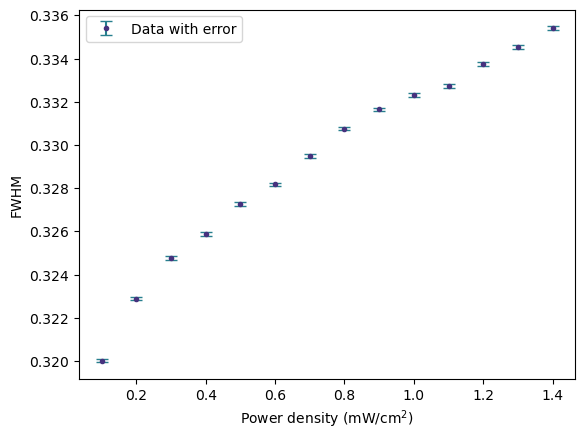

<Figure size 640x480 with 0 Axes>

In [ ]:
# Log-log plot with error bars
x=power_list
y=fwhm_list
y_error= fwhm_error_list
plt.errorbar(x, y, yerr=y_error, fmt='o', color=(0.275191, 0.194905, 0.496005), ecolor=(0.153364, 0.497, 0.557724), capsize=4, ms=3,label="Data with error")


plt.xlabel("Excitation power (mW)")
plt.ylabel("FWHM (eV)")
#plt.title("FWHM vs. excitation power")
plt.legend()
plt.show()
plt.savefig("fwhm.jpg")

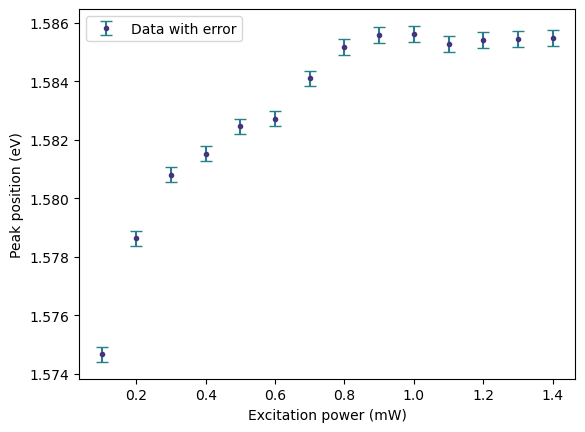

In [187]:
# Log-log plot with error bars
x=power_list
y=peak_pos_list
y_error= peak_err_list
plt.errorbar(x, y, yerr=y_error, fmt='o', color=(0.275191, 0.194905, 0.496005), ecolor=(0.153364, 0.497, 0.557724), capsize=4, ms=3,label="Data with error")


plt.xlabel("Excitation power (mW)")
plt.ylabel("Peak position (eV)")
#plt.title("Peak position vs. excitation power")
plt.legend()
plt.savefig("figs/peak_pos.png", dpi=600, format="png")
plt.show()